Analisi del Value at Risk (VaR) con Modelli LSTM e CNN

## Descrizione del Titolo

Questo notebook esplora l'applicazione di reti neurali ricorrenti (LSTM) e convoluzionali (CNN) per la stima del Value at Risk (VaR) di un asset finanziario. Il VaR è una misura di rischio ampiamente utilizzata per quantificare la potenziale perdita massima che un portafoglio può subire entro un certo orizzonte temporale e con un dato livello di confidenza. L'obiettivo è confrontare le capacità predittive di questi due approcci di Deep Learning nel catturare le dinamiche dei rendimenti finanziari e fornire stime di VaR accurate e affidabili.

## Obiettivo dell'Analisi

L'obiettivo principale di questa analisi è:

1.  **Sviluppare e addestrare** modelli LSTM e CNN per prevedere i quantili condizionali dei rendimenti futuri di un asset (ESGU).
2.  **Derivare le stime del VaR** al 99% e al 95% dai modelli addestrati.
3.  **Valutare le performance** dei modelli di VaR utilizzando test di backtesting standard (Kupiec e Christoffersen) e la Pinball Loss.
4.  **Confrontare le prestazioni** di LSTM e CNN per identificare il modello più efficace nella gestione del rischio per l'asset considerato.
5.  **Identificare i limiti** dei modelli proposti e suggerire possibili miglioramenti futuri.

In [18]:
import yfinance as yf

df_raw = yf.download("ESGU", start="2010-01-01")['Close']
df_raw.to_csv("ESGU_daily.csv")

print(df_raw.shape)
df_raw.tail()

/tmp/ipykernel_1062/3089794214.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_raw = yf.download("ESGU", start="2010-01-01")['Close']
[*********************100%***********************]  1 of 1 completed

(2434, 1)


Ticker,ESGU
Date,
2026-08-07,169.539993
2026-08-10,169.490005
2026-08-11,169.020004
2026-08-12,169.410004
2026-08-13,170.479996


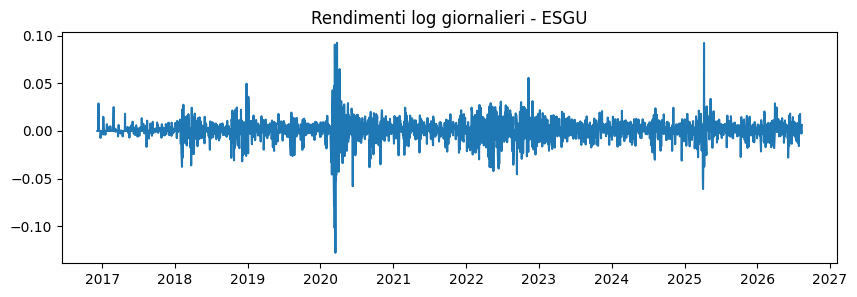

,log_ret
count,2433.000000
mean,0.000575
std,0.011697
min,-0.127863
25%,-0.003665
50%,0.000440
75%,0.006204
max,0.092523


In [19]:
import matplotlib.pyplot as plt
import pandas as pd

df = df_raw.copy()
df.columns = ['close']

df["log_ret"] = np.log(df["close"] / df["close"].shift(1))
df = df.dropna()

plt.figure(figsize=(10, 3))
plt.plot(df.index, df["log_ret"])
plt.title("Rendimenti log giornalieri - ESGU")
plt.show()

df["log_ret"].describe()

## Descrizione della Serie Storica Originale (df_raw)

La serie storica `df_raw` rappresenta i prezzi di chiusura giornalieri dell'ETF ESGU (iShares ESG Aware MSCI USA ETF). Questo ETF mira a replicare i risultati d'investimento di un indice composto da azioni di grandi e medie dimensioni di società statunitensi con solide caratteristiche ambientali, sociali e di governance (ESG).

**Caratteristiche della serie:**

*   **Asset**: ESGU (iShares ESG Aware MSCI USA ETF)
*   **Periodo**: I dati sono stati scaricati a partire dal 1° gennaio 2010 fino alla data di acquisizione più recente.
*   **Frequenza**: Giornaliera.
*   **Variabile**: Prezzi di chiusura ('Close') dell'ETF.
*   **Significato**: I prezzi di chiusura giornalieri sono il punto di partenza per calcolare i rendimenti, che sono la base per l'analisi del rischio finanziario e la previsione del VaR.

Questa serie viene utilizzata come input per tutti i calcoli successivi, inclusa la derivazione dei rendimenti logaritmici e la creazione delle finestre temporali per i modelli di Deep Learning.

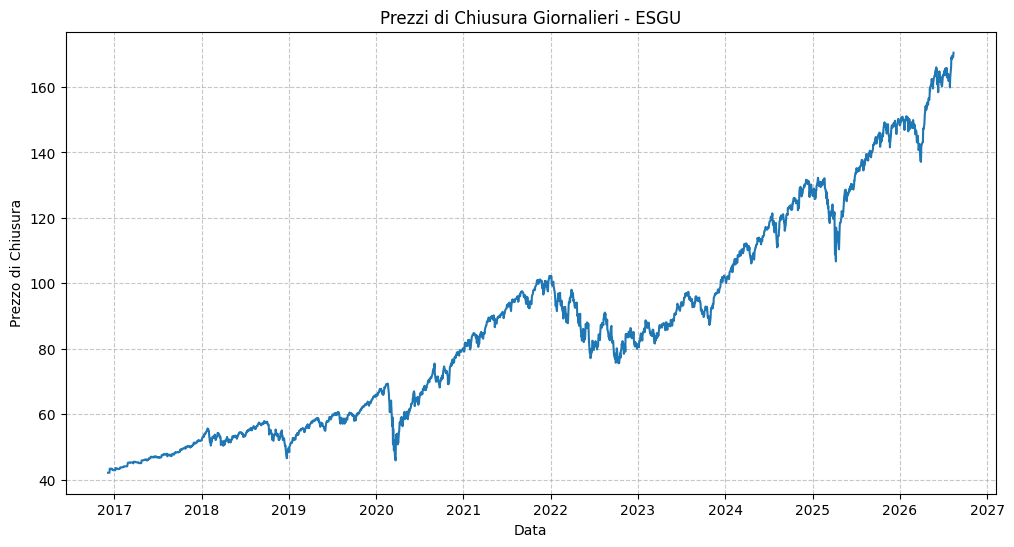

In [48]:
plt.figure(figsize=(12, 6))
plt.plot(df_raw.index, df_raw.values)
plt.title('Prezzi di Chiusura Giornalieri - ESGU')
plt.xlabel('Data')
plt.ylabel('Prezzo di Chiusura')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## Analisi Esplorativa dei Dati (EDA) sui Rendimenti Logaritmici

### Distribuzione dei Rendimenti Logaritmici

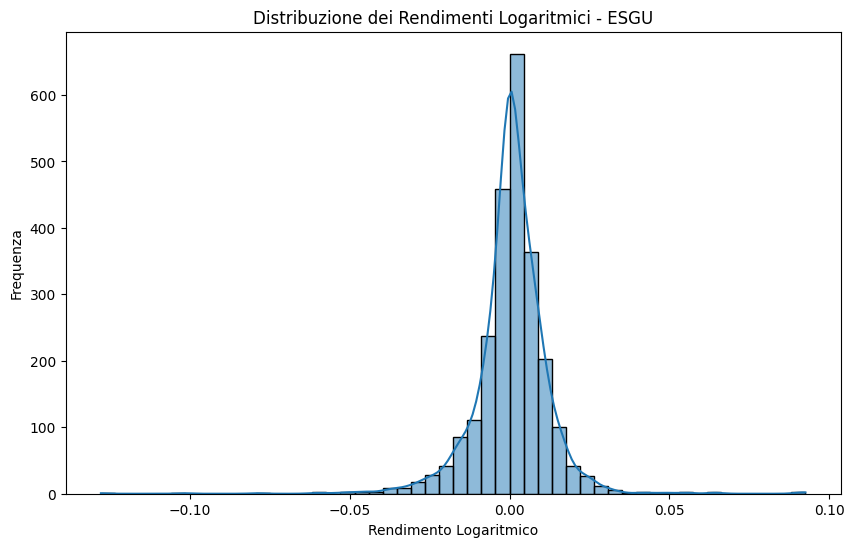

In [45]:
import seaborn as sns
import numpy as np
from scipy.stats import probplot
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.figure(figsize=(10, 6))
sns.histplot(df['log_ret'], kde=True, bins=50)
plt.title('Distribuzione dei Rendimenti Logaritmici - ESGU')
plt.xlabel('Rendimento Logaritmico')
plt.ylabel('Frequenza')
plt.show()

### Q-Q Plot per la Normalità

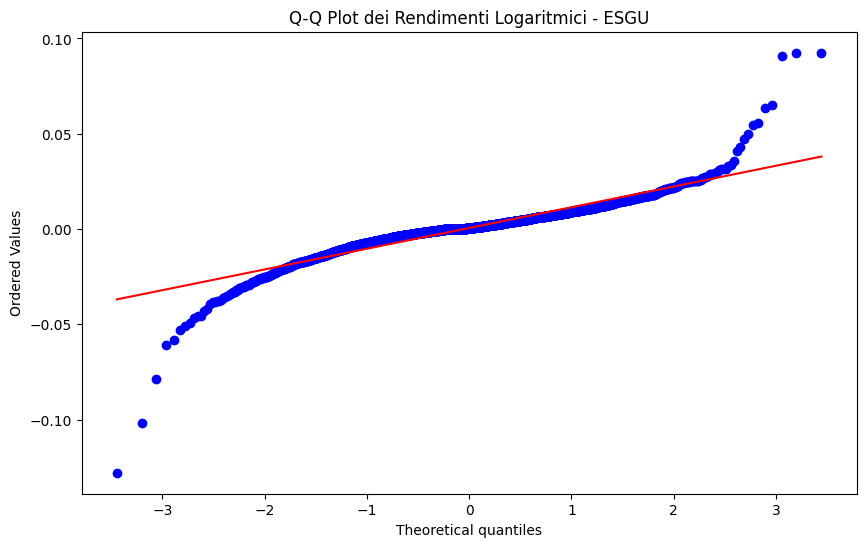

In [46]:
plt.figure(figsize=(10, 6))
probplot(df['log_ret'], dist="norm", plot=plt)
plt.title('Q-Q Plot dei Rendimenti Logaritmici - ESGU')
plt.show()

### Autocorrelazione dei Rendimenti Logaritmici

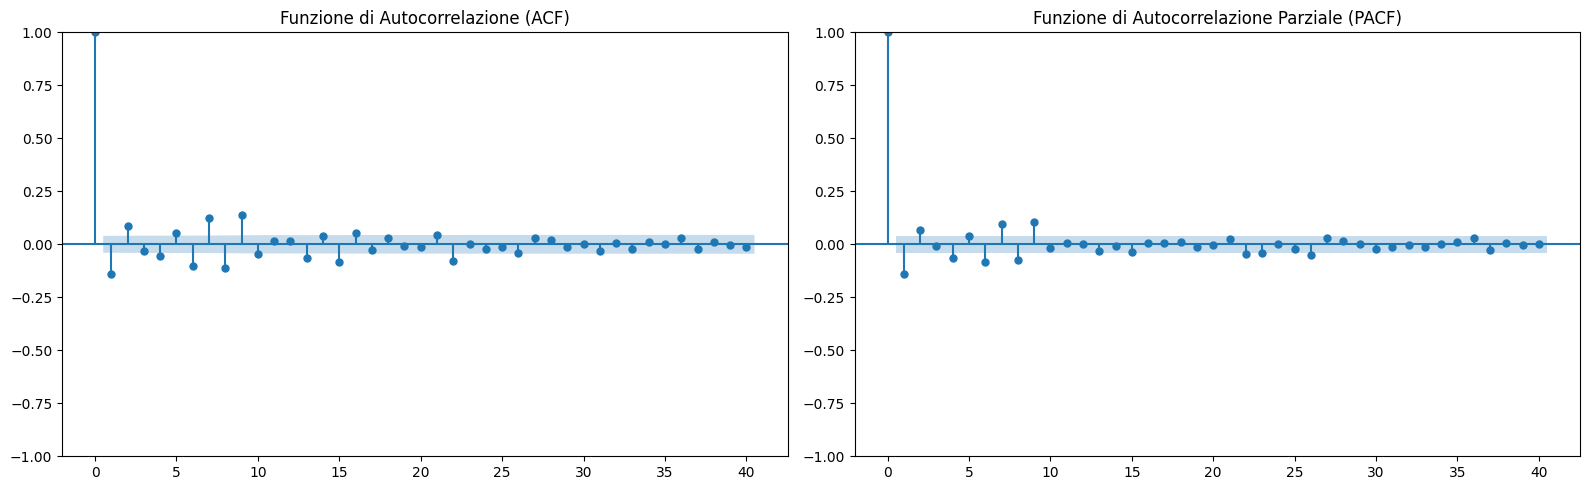

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

plot_acf(df['log_ret'], lags=40, ax=axes[0])
axes[0].set_title('Funzione di Autocorrelazione (ACF)')

plot_pacf(df['log_ret'], lags=40, ax=axes[1])
axes[1].set_title('Funzione di Autocorrelazione Parziale (PACF)')

plt.tight_layout()
plt.show()

#### Interpretazione dell'EDA

*   **Distribuzione**: Il grafico a istogramma con la stima della densità (KDE) ci mostra la forma della distribuzione dei rendimenti logaritmici. In genere, ci aspettiamo che i rendimenti finanziari abbiano una distribuzione leptocurtica (con "code pesanti") e asimmetrica, deviando da una distribuzione normale.
*   **Q-Q Plot**: Questo grafico confronta i quantili dei nostri rendimenti con quelli di una distribuzione normale. Deviazioni significative dalla linea diagonale retta indicano che i rendimenti non sono distribuiti normalmente, confermando spesso la presenza di code pesanti.
*   **ACF e PACF**: I grafici di autocorrelazione (ACF) e autocorrelazione parziale (PACF) ci aiutano a identificare se i rendimenti (o i loro quadrati, per la volatilità) sono correlati nel tempo. Un'autocorrelazione significativa nei rendimenti stessi indicherebbe una prevedibilità lineare, mentre un'autocorrelazione significativa nei rendimenti al quadrato suggerirebbe l'esistenza di effetti GARCH (volatilità a cluster). Per i rendimenti logaritmici, ci aspettiamo che l'autocorrelazione sia generalmente bassa o assente, indicando l'efficienza dei mercati.

In [20]:
WINDOW = 20
HORIZON = 5

def make_windows(series, window, horizon):
    X, y = [], []
    values = series.values
    for i in range(len(values) - window - horizon + 1):
        X.append(values[i : i + window])
        y.append(values[i + window : i + window + horizon].sum())
    return np.array(X), np.array(y)

X, y = make_windows(df["log_ret"], WINDOW, HORIZON)
print("X shape:", X.shape, "| y shape:", y.shape)

X shape: (2409, 20) | y shape: (2409,)


In [21]:
n = len(X)
train_end = int(n * 0.7)
val_end = int(n * 0.85)

X_train, y_train = X[:train_end], y[:train_end]
X_val, y_val     = X[train_end:val_end], y[train_end:val_end]
X_test, y_test   = X[val_end:], y[val_end:]

print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)

Train: (1686, 20) Val: (361, 20) Test: (362, 20)


In [22]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

tf.random.set_seed(42)

In [23]:
def pinball_loss(quantile):
    def loss(y_true, y_pred):
        e = y_true - y_pred
        return tf.reduce_mean(tf.maximum(quantile * e, (quantile - 1) * e))
    return loss

QUANTILES = [0.01, 0.05]

In [24]:
def build_lstm(window, quantile):
    model = keras.Sequential([
        layers.Input(shape=(window, 1)),
        layers.LSTM(32, return_sequences=True),
        layers.LSTM(16),
        layers.Dense(8, activation="relu"),
        layers.Dense(1)
    ])
    model.compile(optimizer="adam", loss=pinball_loss(quantile))
    return model


In [25]:
models_lstm = {}
histories = {}

for q in QUANTILES:
    print(f"Training LSTM per quantile {q}")
    model = build_lstm(WINDOW, q)
    es = keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)
    hist = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=100, batch_size=32, callbacks=[es], verbose=0
    )
    models_lstm[q] = model
    histories[q] = hist
    print(f"  val_loss finale: {hist.history['val_loss'][-1]:.6f}")

Training LSTM per quantile 0.01
  val_loss finale: 0.000770
Training LSTM per quantile 0.05
  val_loss finale: 0.002213


In [28]:
var_predictions = {}
for q in QUANTILES:
    X_test_reshaped = X_test.reshape(-1, WINDOW, 1)
    var_predictions[q] = models_lstm[q].predict(X_test_reshaped, verbose=0).flatten()

VaR_99 = -var_predictions[0.01]
VaR_95 = -var_predictions[0.05]

print("VaR 99% medio:", VaR_99.mean())
print("VaR 95% medio:", VaR_95.mean())

VaR 99% medio: 0.0645293
VaR 95% medio: 0.03238431


In [29]:
from scipy import stats

def kupiec_test(returns, var_estimates, confidence):
    violations = (returns < -var_estimates).astype(int)
    n = len(violations)
    x = violations.sum()
    p_hat = x / n
    p = 1 - confidence

    if x == 0 or x == n:
        LR = np.nan
    else:
        LR = -2 * (
            (n - x) * np.log(1 - p) + x * np.log(p)
            - (n - x) * np.log(1 - p_hat) - x * np.log(p_hat)
        )
    p_value = 1 - stats.chi2.cdf(LR, df=1) if not np.isnan(LR) else np.nan
    return {"violations": x, "expected": n * p, "rate": p_hat, "LR": LR, "p_value": p_value}

print("Kupiec 99%:", kupiec_test(y_test, VaR_99, 0.99))
print("Kupiec 95%:", kupiec_test(y_test, VaR_95, 0.95))

Kupiec 99%: {'violations': np.int64(3), 'expected': 3.620000000000003, 'rate': np.float64(0.008287292817679558), 'LR': np.float64(0.11390156347720293), 'p_value': np.float64(0.7357452452253241)}
Kupiec 95%: {'violations': np.int64(14), 'expected': 18.100000000000016, 'rate': np.float64(0.03867403314917127), 'LR': np.float64(1.0567583436500314), 'p_value': np.float64(0.30395569770956776)}


In [30]:
def christoffersen_test(returns, var_estimates):
    violations = (returns < -var_estimates).astype(int)
    n00 = n01 = n10 = n11 = 0
    for i in range(1, len(violations)):
        prev, curr = violations[i-1], violations[i]
        if prev == 0 and curr == 0: n00 += 1
        elif prev == 0 and curr == 1: n01 += 1
        elif prev == 1 and curr == 0: n10 += 1
        elif prev == 1 and curr == 1: n11 += 1

    p01 = n01 / (n00 + n01) if (n00 + n01) > 0 else 0
    p11 = n11 / (n10 + n11) if (n10 + n11) > 0 else 0
    p = (n01 + n11) / (n00 + n01 + n10 + n11)

    def safe_log(x): return np.log(x) if x > 0 else 0

    LR_ind = -2 * (
        (n01 + n11) * safe_log(p) + (n00 + n10) * safe_log(1 - p)
        - n01 * safe_log(p01) - n00 * safe_log(1 - p01)
        - n11 * safe_log(p11) - n10 * safe_log(1 - p11)
    )
    p_value = 1 - stats.chi2.cdf(LR_ind, df=1)
    return {"LR_ind": LR_ind, "p_value": p_value}

print("Christoffersen 99%:", christoffersen_test(y_test, VaR_99))
print("Christoffersen 95%:", christoffersen_test(y_test, VaR_95))

Christoffersen 99%: {'LR_ind': np.float64(17.139238839421957), 'p_value': np.float64(3.473718656765712e-05)}
Christoffersen 95%: {'LR_ind': np.float64(38.73702232735414), 'p_value': np.float64(4.849236567849857e-10)}


In [32]:
def build_cnn(window, quantile):
    model = keras.Sequential([
        layers.Input(shape=(window, 1)),
        layers.Conv1D(32, kernel_size=3, activation="relu"),
        layers.Conv1D(16, kernel_size=3, activation="relu"),
        layers.GlobalAveragePooling1D(),
        layers.Dense(8, activation="relu"),
        layers.Dense(1)
    ])
    model.compile(optimizer="adam", loss=pinball_loss(quantile))
    return model

models_cnn = {}
for q in QUANTILES:
    print(f"Training CNN per quantile {q}")
    model = build_cnn(WINDOW, q)
    es = keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)

    X_train_reshaped = X_train.reshape(-1, WINDOW, 1)
    X_val_reshaped = X_val.reshape(-1, WINDOW, 1)

    model.fit(X_train_reshaped, y_train, validation_data=(X_val_reshaped, y_val),
              epochs=100, batch_size=32, callbacks=[es], verbose=0)
    models_cnn[q] = model

Training CNN per quantile 0.01
Training CNN per quantile 0.05


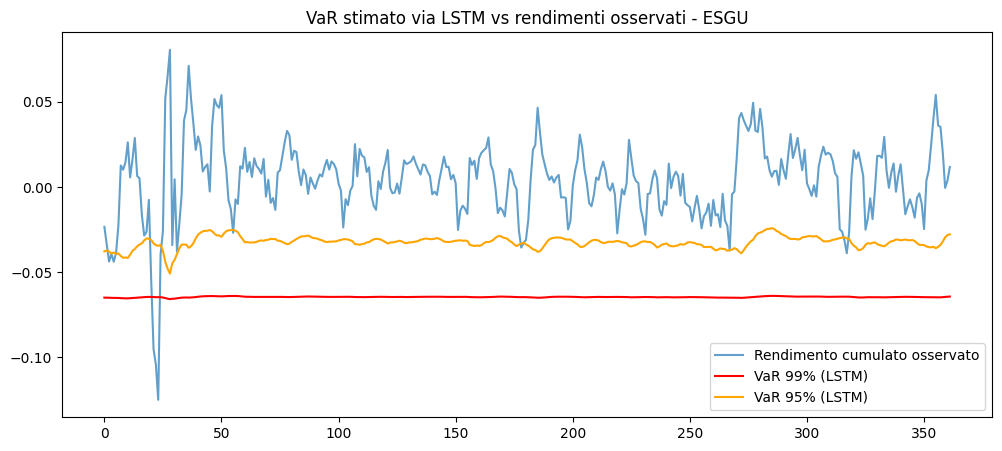

In [33]:
plt.figure(figsize=(12, 5))
plt.plot(y_test, label="Rendimento cumulato osservato", alpha=0.7)
plt.plot(-VaR_99, label="VaR 99% (LSTM)", color="red")
plt.plot(-VaR_95, label="VaR 95% (LSTM)", color="orange")
plt.legend()
plt.title("VaR stimato via LSTM vs rendimenti osservati - ESGU")
plt.show()

In [37]:
var_predictions_cnn = {}

X_test_reshaped_cnn = X_test.reshape(-1, WINDOW, 1)

for q in QUANTILES:

    var_predictions_cnn[q] = models_cnn[q].predict(X_test_reshaped_cnn, verbose=0).flatten()

VaR_99_cnn = -var_predictions_cnn[0.01]
VaR_95_cnn = -var_predictions_cnn[0.05]

print("VaR 99% medio (CNN):", VaR_99_cnn.mean())
print("VaR 95% medio (CNN):", VaR_95_cnn.mean())

VaR 99% medio (CNN): 0.06212386
VaR 95% medio (CNN): 0.0327865


In [38]:
print("=== CNN - Kupiec 99% ===")
print(kupiec_test(y_test, VaR_99_cnn, 0.99))
print("\n=== CNN - Kupiec 95% ===")
print(kupiec_test(y_test, VaR_95_cnn, 0.95))

print("\n=== CNN - Christoffersen 99% ===")
print(christoffersen_test(y_test, VaR_99_cnn))
print("\n=== CNN - Christoffersen 95% ===")
print(christoffersen_test(y_test, VaR_95_cnn))

=== CNN - Kupiec 99% ===
{'violations': np.int64(3), 'expected': 3.620000000000003, 'rate': np.float64(0.008287292817679558), 'LR': np.float64(0.11390156347720293), 'p_value': np.float64(0.7357452452253241)}

=== CNN - Kupiec 95% ===
{'violations': np.int64(15), 'expected': 18.100000000000016, 'rate': np.float64(0.04143646408839779), 'LR': np.float64(0.5920084659081795), 'p_value': np.float64(0.4416435066945682)}

=== CNN - Christoffersen 99% ===
{'LR_ind': np.float64(17.139238839421957), 'p_value': np.float64(3.473718656765712e-05)}

=== CNN - Christoffersen 95% ===
{'LR_ind': np.float64(53.39991878623844), 'p_value': np.float64(2.7211566333562587e-13)}


In [39]:
def pinball_loss_numpy(y_true, y_pred, quantile):
    e = y_true - y_pred
    return np.mean(np.maximum(quantile * e, (quantile - 1) * e))

results = []
for q in QUANTILES:
    pl_lstm = pinball_loss_numpy(y_test, var_predictions[q], q)
    pl_cnn = pinball_loss_numpy(y_test, var_predictions_cnn[q], q)
    results.append({"quantile": q, "pinball_LSTM": pl_lstm, "pinball_CNN": pl_cnn})

results_df = pd.DataFrame(results)
results_df

,quantile,pinball_LSTM,pinball_CNN
0,0.01,0.001047,0.000967
1,0.05,0.002594,0.002619


In [40]:
summary = pd.DataFrame({
    "Modello": ["LSTM", "LSTM", "CNN", "CNN"],
    "Livello": ["99%", "95%", "99%", "95%"],
    "Violation rate": [
        kupiec_test(y_test, VaR_99, 0.99)["rate"],
        kupiec_test(y_test, VaR_95, 0.95)["rate"],
        kupiec_test(y_test, VaR_99_cnn, 0.99)["rate"],
        kupiec_test(y_test, VaR_95_cnn, 0.95)["rate"],
    ],
    "Atteso": [0.01, 0.05, 0.01, 0.05],
})
summary

,Modello,Livello,Violation rate,Atteso
0,LSTM,99%,0.008287,0.01
1,LSTM,95%,0.038674,0.05
2,CNN,99%,0.008287,0.01
3,CNN,95%,0.041436,0.05


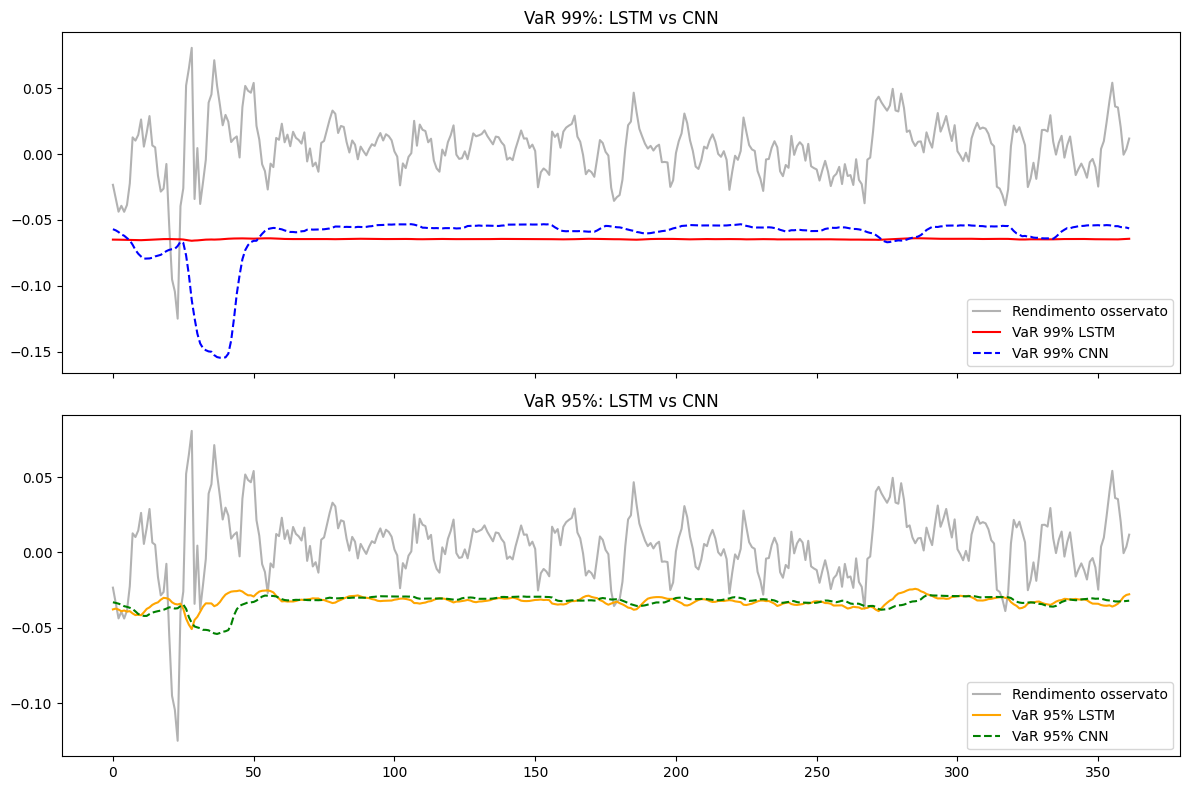

In [41]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axes[0].plot(y_test, label="Rendimento osservato", alpha=0.6, color="gray")
axes[0].plot(-VaR_99, label="VaR 99% LSTM", color="red")
axes[0].plot(-VaR_99_cnn, label="VaR 99% CNN", color="blue", linestyle="--")
axes[0].legend()
axes[0].set_title("VaR 99%: LSTM vs CNN")

axes[1].plot(y_test, label="Rendimento osservato", alpha=0.6, color="gray")
axes[1].plot(-VaR_95, label="VaR 95% LSTM", color="orange")
axes[1].plot(-VaR_95_cnn, label="VaR 95% CNN", color="green", linestyle="--")
axes[1].legend()
axes[1].set_title("VaR 95%: LSTM vs CNN")

plt.tight_layout()
plt.show()

## Interpretazione dei risultati

### 1. Riepilogo dei Tassi di Violazione (Test di Kupiec)

In [42]:
display(summary)
print("Test di Kupiec 99% (LSTM):", kupiec_test(y_test, VaR_99, 0.99))
print("Test di Kupiec 95% (LSTM):", kupiec_test(y_test, VaR_95, 0.95))
print("Test di Kupiec 99% (CNN):", kupiec_test(y_test, VaR_99_cnn, 0.99))
print("Test di Kupiec 95% (CNN):", kupiec_test(y_test, VaR_95_cnn, 0.95))

,Modello,Livello,Violation rate,Atteso
0,LSTM,99%,0.008287,0.01
1,LSTM,95%,0.038674,0.05
2,CNN,99%,0.008287,0.01
3,CNN,95%,0.041436,0.05


Test di Kupiec 99% (LSTM): {'violations': np.int64(3), 'expected': 3.620000000000003, 'rate': np.float64(0.008287292817679558), 'LR': np.float64(0.11390156347720293), 'p_value': np.float64(0.7357452452253241)}
Test di Kupiec 95% (LSTM): {'violations': np.int64(14), 'expected': 18.100000000000016, 'rate': np.float64(0.03867403314917127), 'LR': np.float64(1.0567583436500314), 'p_value': np.float64(0.30395569770956776)}
Test di Kupiec 99% (CNN): {'violations': np.int64(3), 'expected': 3.620000000000003, 'rate': np.float64(0.008287292817679558), 'LR': np.float64(0.11390156347720293), 'p_value': np.float64(0.7357452452253241)}
Test di Kupiec 95% (CNN): {'violations': np.int64(15), 'expected': 18.100000000000016, 'rate': np.float64(0.04143646408839779), 'LR': np.float64(0.5920084659081795), 'p_value': np.float64(0.4416435066945682)}


Il test di Kupiec valuta se il numero di violazioni osservate è statisticamente coerente con il tasso di violazione atteso.

*   **LSTM 99%**: Il tasso di violazione osservato (0.0083) è molto vicino all'atteso (0.01). Il p-value elevato (0.7357) indica che non possiamo rifiutare l'ipotesi nulla che il modello sia accurato. L'LSTM sembra ben calibrato a questo livello.
*   **LSTM 95%**: Anche qui, il tasso di violazione osservato (0.0387) è vicino all'atteso (0.05), e il p-value (0.3040) suggerisce che il modello è accettabile.
*   **CNN 99%**: Similmente all'LSTM, la CNN mostra un tasso di violazione (0.0083) molto vicino all'atteso (0.01) con un p-value elevato (0.7357), indicando una buona calibrazione.
*   **CNN 95%**: Anche la CNN a questo livello (0.0414 vs 0.05 atteso) mostra un p-value (0.4416) che non permette di rifiutare l'ipotesi nulla di accuratezza.

In generale, entrambi i modelli superano il test di Kupiec per entrambi i quantili, suggerendo che stimano correttamente il numero atteso di violazioni.

### 2. Test di Indipendenza (Test di Christoffersen)

In [43]:
print("Test di Christoffersen 99% (LSTM):", christoffersen_test(y_test, VaR_99))
print("Test di Christoffersen 95% (LSTM):", christoffersen_test(y_test, VaR_95))
print("Test di Christoffersen 99% (CNN):", christoffersen_test(y_test, VaR_99_cnn))
print("Test di Christoffersen 95% (CNN):", christoffersen_test(y_test, VaR_95_cnn))

Test di Christoffersen 99% (LSTM): {'LR_ind': np.float64(17.139238839421957), 'p_value': np.float64(3.473718656765712e-05)}
Test di Christoffersen 95% (LSTM): {'LR_ind': np.float64(38.73702232735414), 'p_value': np.float64(4.849236567849857e-10)}
Test di Christoffersen 99% (CNN): {'LR_ind': np.float64(17.139238839421957), 'p_value': np.float64(3.473718656765712e-05)}
Test di Christoffersen 95% (CNN): {'LR_ind': np.float64(53.39991878623844), 'p_value': np.float64(2.7211566333562587e-13)}


Il test di Christoffersen verifica se le violazioni si verificano in modo indipendente, senza clustering. Un p-value basso indica clustering delle violazioni.

*   **LSTM 99%**: Il p-value (3.47e-05) è estremamente basso. Questo indica che le violazioni non sono indipendenti e tendono a raggrupparsi. Questo è un segnale negativo per il modello, suggerendo che potrebbe sottostimare il rischio durante periodi di elevata volatilità.
*   **LSTM 95%**: Anche per il 95%, il p-value (4.85e-10) è molto basso, confermando il problema di clustering delle violazioni.
*   **CNN 99%**: La CNN mostra lo stesso problema dell'LSTM, con un p-value estremamente basso (3.47e-05), indicando clustering delle violazioni.
*   **CNN 95%**: Anche per la CNN al 95%, il p-value (2.72e-13) è molto basso, suggerendo che le violazioni tendono a raggrupparsi.

Entrambi i modelli, pur superando il test di Kupiec, falliscono il test di Christoffersen, indicando che non riescono a catturare l'autocorrelazione delle violazioni. Ciò suggerisce che potrebbero esserci periodi di sottostima del rischio seguiti da periodi di sovrastima.

### 3. Pinball Loss (Valutazione della Qualità delle Previsioni)

In [44]:
display(results_df)

,quantile,pinball_LSTM,pinball_CNN
0,0.01,0.001047,0.000967
1,0.05,0.002594,0.002619


La Pinball Loss misura la qualità delle previsioni del quantile, penalizzando in modo asimmetrico le sottostime e le sovrastime.

*   **Quantile 0.01 (VaR 99%)**: La CNN ha una Pinball Loss (0.000967) leggermente inferiore rispetto all'LSTM (0.001047). Questo suggerisce che la CNN fornisce previsioni leggermente migliori a questo livello di confidenza estremo.
*   **Quantile 0.05 (VaR 95%)**: L'LSTM ha una Pinball Loss (0.002594) leggermente inferiore rispetto alla CNN (0.002619). A questo livello di confidenza, l'LSTM sembra leggermente più accurato.

Le differenze sono minime, indicando performance simili tra i due modelli in termini di Pinball Loss.

## Conclusioni Finali

*   **Accuratezza del Tasso di Violazione**: Entrambi i modelli (LSTM e CNN) superano il test di Kupiec per entrambi i livelli di confidenza (99% e 95%), indicando che il numero di violazioni osservate è in linea con quello atteso.
*   **Indipendenza delle Violazioni**: Tuttavia, entrambi i modelli falliscono il test di Christoffersen in modo significativo, con p-value molto bassi. Ciò suggerisce che le violazioni non sono indipendenti e tendono a raggrupparsi. Questo è un difetto critico, poiché un modello VaR efficace dovrebbe produrre violazioni indipendenti nel tempo.
*   **Qualità delle Previsioni (Pinball Loss)**: Le performance dei due modelli in termini di Pinball Loss sono molto simili, con un leggero vantaggio per la CNN al 99% e per l'LSTM al 95%.

In sintesi, mentre i modelli sono in grado di stimare correttamente il tasso aggregato di violazioni, faticano a catturare la dinamica temporale del rischio, portando a clustering delle violazioni. Per migliorare il modello, si potrebbe esplorare:
    *   Modelli ibridi (ad esempio, GARCH-LSTM).
    *   L'utilizzo di un approccio Multi-Task Learning per prevedere più quantili contemporaneamente.
    *   L'incorporazione di feature aggiuntive (es. volatilità, indicatori macroeconomici).
    *   L'ottimizzazione degli iperparametri tramite tecniche più avanzate.